# Data Processing & Panel Dataset Creation
This notebook processes all raw data from `data/raw/` and creates the final panel dataset in `data/processed/`.

**Input:** Raw CSV files in `data/raw/`
- eurostat_gva.csv
- eurostat_ppi.csv
- eu_ets_carbon_prices.csv
- ghg_emissions.csv
- ets_compliance.csv
- power_carbon_intensity.csv

**Output:** `data/processed/panel_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Configuration

In [2]:
# Paths
DATA_RAW = Path('../../data/raw')
DATA_PROCESSED = Path('../../data/processed')
DATA_PROCESSED.mkdir(exist_ok=True, parents=True)

COUNTRIES = {
    'DE': 'Germany',
    'FR': 'France',
    'IT': 'Italy',
    'PL': 'Poland',
    'ES': 'Spain',
    'NL': 'Netherlands'
}

START_YEAR = 2010
END_YEAR = 2024

## 2. Load Raw Datasets

In [4]:
def load_dataset(filename, description):
    filepath = DATA_RAW / filename
    try:
        df = pd.read_csv(filepath)
        print(f"{description:30s} {len(df):4d} rows, {len(df.columns):2d} cols")
        return df
    except FileNotFoundError:
        print("Error")
        return None

df_gva = load_dataset('eurostat_gva.csv', 'GVA (Industrial Output)')
df_ppi = load_dataset('eurostat_ppi.csv', 'PPI (Producer Price Index)')
df_carbon = load_dataset('eu_ets_carbon_prices.csv', 'EU ETS Carbon Prices')
df_emissions = load_dataset('ghg_emissions.csv', 'GHG Emissions')
df_ets = load_dataset('ets_compliance.csv', 'ETS Compliance')
df_power = load_dataset('power_carbon_intensity.csv', 'Power Carbon Intensity')

GVA (Industrial Output)          90 rows,  9 cols
PPI (Producer Price Index)       90 rows,  5 cols
EU ETS Carbon Prices             15 rows,  8 cols
GHG Emissions                    90 rows,  6 cols
ETS Compliance                   90 rows,  7 cols
Power Carbon Intensity           90 rows,  4 cols


## 4. Merge Datasets into Panel

In [6]:
panel = df_gva.copy()

# Merge PPI
if df_ppi is not None:
    cols = ['country_code', 'year', 'ppi_index_2015']
    if 'ppi_inflation_pct' in df_ppi.columns:
        cols.append('ppi_inflation_pct')
    panel = panel.merge(df_ppi[cols], on=['country_code', 'year'], how='left')

# Merge Carbon Prices (no country dimension - same for all)
if df_carbon is not None:
    cols = ['year', 'carbon_price_eur_tonne']
    for col in ['ets_phase', 'msr_active', 'high_price_regime', 'price_regime']:
        if col in df_carbon.columns:
            cols.append(col)
    panel = panel.merge(df_carbon[cols], on='year', how='left')

# Merge Emissions
if df_emissions is not None:
    cols = ['country_code', 'year', 'total_ghg_mt_co2eq']
    for col in ['emissions_yoy_pct', 'reduction_from_2010_pct']:
        if col in df_emissions.columns:
            cols.append(col)
    panel = panel.merge(df_emissions[cols], on=['country_code', 'year'], how='left')

# Merge ETS Compliance
if df_ets is not None:
    cols = ['country_code', 'year']
    for col in ['verified_emissions_mt', 'free_allocation_ratio_pct', 
                'free_allowances_mt', 'net_purchase_required_mt']:
        if col in df_ets.columns:
            cols.append(col)
    panel = panel.merge(df_ets[cols], on=['country_code', 'year'], how='left')

# Merge Power Carbon Intensity
if df_power is not None:
    cols = ['country_code', 'year', 'carbon_intensity_gco2_kwh']
    panel = panel.merge(df_power[cols], on=['country_code', 'year'], how='left')

print(f"\nMerged panel: {panel.shape[0]} rows × {panel.shape[1]} columns")


Merged panel: 90 rows × 24 columns


## 5. Create Derived Variables

In [7]:
print("\nCreating derived variables...")
print("=" * 70)

# 1. Economic carbon intensity (emissions per EUR of output)
if 'total_ghg_mt_co2eq' in panel.columns and 'gva_industry_meur' in panel.columns:
    panel['carbon_intensity_t_per_meur'] = (panel['total_ghg_mt_co2eq'] * 1e6) / panel['gva_industry_meur']
    panel['carbon_intensity_t_per_meur'] = panel['carbon_intensity_t_per_meur'].round(2)
    print("✓ Carbon intensity (t CO2 per M€ output)")

# 2. Effective carbon cost burden
if all(col in panel.columns for col in ['net_purchase_required_mt', 'carbon_price_eur_tonne']):
    panel['effective_carbon_cost_meur'] = panel['net_purchase_required_mt'] * panel['carbon_price_eur_tonne']
    panel['carbon_cost_burden_pct'] = (panel['effective_carbon_cost_meur'] / panel['gva_industry_meur'] * 100).round(2)
    print("✓ Carbon cost burden (% of GVA)")

# 3. Real GVA (inflation-adjusted)
if 'ppi_index_2015' in panel.columns:
    panel['gva_industry_real_meur'] = (panel['gva_industry_meur'] * 100 / panel['ppi_index_2015']).round(2)
    if 'gva_total_meur' in panel.columns:
        panel['gva_total_real_meur'] = (panel['gva_total_meur'] * 100 / panel['ppi_index_2015']).round(2)
    print("✓ Real GVA (2015 constant prices)")

# 4. Growth rates
if 'gva_industry_meur' in panel.columns:
    panel['industry_growth_pct'] = (panel.groupby('country_code')['gva_industry_meur']
                                     .pct_change() * 100).round(2)
if 'gva_total_meur' in panel.columns:
    panel['gdp_growth_pct'] = (panel.groupby('country_code')['gva_total_meur']
                                .pct_change() * 100).round(2)
print("✓ Growth rates (YoY %)")

# 5. Decoupling index (economic growth - emissions growth)
if all(col in panel.columns for col in ['gdp_growth_pct', 'emissions_yoy_pct']):
    panel['decoupling_index'] = (panel['gdp_growth_pct'] - panel['emissions_yoy_pct']).round(2)
    print("✓ Decoupling index (GDP growth - emission growth)")

# 6. Period indicators
panel['covid_period'] = ((panel['year'] >= 2020) & (panel['year'] <= 2021)).astype(int)
panel['energy_crisis'] = ((panel['year'] >= 2022) & (panel['year'] <= 2023)).astype(int)
panel['ets_phase_3'] = ((panel['year'] >= 2013) & (panel['year'] <= 2020)).astype(int)
panel['ets_phase_4'] = (panel['year'] >= 2021).astype(int)
print("✓ Period dummies (COVID, energy crisis, ETS phases)")

# 7. Lagged variables for regression
if 'carbon_price_eur_tonne' in panel.columns:
    panel['carbon_price_lag1'] = panel.groupby('country_code')['carbon_price_eur_tonne'].shift(1).round(2)
    panel['carbon_price_lag2'] = panel.groupby('country_code')['carbon_price_eur_tonne'].shift(2).round(2)
    print("✓ Lagged carbon prices (t-1, t-2)")

# 8. Log transformations for regression
panel['ln_gva_industry'] = np.log(panel['gva_industry_meur']).round(4)
panel['ln_gva_total'] = np.log(panel['gva_total_meur']).round(4) if 'gva_total_meur' in panel.columns else np.nan
if 'carbon_price_eur_tonne' in panel.columns:
    panel['ln_carbon_price'] = np.log(panel['carbon_price_eur_tonne']).round(4)
if 'total_ghg_mt_co2eq' in panel.columns:
    panel['ln_emissions'] = np.log(panel['total_ghg_mt_co2eq']).round(4)
print("✓ Log transformations (for elasticity estimation)")

# Sort by country and year
panel = panel.sort_values(['country_code', 'year']).reset_index(drop=True)

print(f"\nFinal panel: {panel.shape[0]} rows × {panel.shape[1]} columns")


Creating derived variables...
✓ Carbon intensity (t CO2 per M€ output)
✓ Carbon cost burden (% of GVA)
✓ Real GVA (2015 constant prices)
✓ Growth rates (YoY %)
✓ Decoupling index (GDP growth - emission growth)
✓ Period dummies (COVID, energy crisis, ETS phases)
✓ Lagged carbon prices (t-1, t-2)
✓ Log transformations (for elasticity estimation)

Final panel: 90 rows × 42 columns


## 6. Data Quality Summary

In [8]:
print("\n" + "=" * 70)
print("DATA QUALITY SUMMARY")
print("=" * 70)

# Basic info
print(f"\nPanel structure:")
print(f"  Countries: {panel['country'].nunique()} ({', '.join(sorted(panel['country'].unique()))})")
print(f"  Years: {panel['year'].min()}-{panel['year'].max()} ({panel['year'].nunique()} years)")
print(f"  Total observations: {len(panel)}")
print(f"  Variables: {len(panel.columns)}")

# Missing values
print(f"\nMissing values:")
missing = panel.isnull().sum()
missing_pct = (missing / len(panel) * 100).round(1)
missing_summary = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_pct
})
missing_vars = missing_summary[missing_summary['Missing'] > 0].sort_values('Missing', ascending=False)
if len(missing_vars) > 0:
    print(missing_vars.head(10))
else:
    print("  No missing values ✓")

# Key statistics
print(f"\nKey variable statistics:")
key_vars = [
    'gva_industry_meur',
    'carbon_price_eur_tonne',
    'total_ghg_mt_co2eq',
    'carbon_intensity_t_per_meur'
]
available_vars = [v for v in key_vars if v in panel.columns]
if available_vars:
    display(panel[available_vars].describe().round(2))


DATA QUALITY SUMMARY

Panel structure:
  Countries: 6 (France, Germany, Italy, Netherlands, Poland, Spain)
  Years: 2010-2024 (15 years)
  Total observations: 90
  Variables: 42

Missing values:
                         Missing  Percentage
carbon_price_lag2             12        13.3
industry_yoy_growth_pct        6         6.7
ppi_inflation_pct              6         6.7
emissions_yoy_pct              6         6.7
industry_growth_pct            6         6.7
gdp_growth_pct                 6         6.7
decoupling_index               6         6.7
carbon_price_lag1              6         6.7

Key variable statistics:


,gva_industry_meur,carbon_price_eur_tonne,total_ghg_mt_co2eq,carbon_intensity_t_per_meur
count,90.00,90.00,90.00,90.00
mean,269758.20,27.40,432.80,1970.40
std,204035.44,27.44,209.43,869.64
min,84240.00,4.46,144.00,948.27
25%,112281.20,5.96,324.25,1426.06
50%,212126.90,14.32,396.00,1709.97
75%,286408.38,53.31,464.00,2036.98
max,744159.60,83.66,948.00,4748.34


## 7. Preview Final Dataset

In [9]:
# Display first few rows
print("\nFirst 10 rows of panel dataset:")
display(panel.head(10))

# Display sample for one country
print("\nSample: Germany (DE) 2010-2024:")
de_sample = panel[panel['country_code'] == 'DE'][[
    'year', 'gva_industry_meur', 'carbon_price_eur_tonne', 
    'total_ghg_mt_co2eq', 'industry_growth_pct'
]]
display(de_sample)


First 10 rows of panel dataset:


,country_code,country,year,gva_industry_meur,gva_manufacturing_meur,gva_total_meur,industry_share_pct,manufacturing_share_pct,industry_yoy_growth_pct,ppi_index_2015,...,covid_period,energy_crisis,ets_phase_3,ets_phase_4,carbon_price_lag1,carbon_price_lag2,ln_gva_industry,ln_gva_total,ln_carbon_price,ln_emissions
0,DE,Germany,2010,617890.8,544972.8,2534283.9,24.38,21.50,NaN,92.3,...,0,0,0,0,NaN,NaN,13.3341,14.7454,2.6617,6.8469
1,DE,Germany,2011,650943.3,594104.7,2629245.3,24.76,22.60,5.349246,97.5,...,0,0,0,0,14.32,NaN,13.3862,14.7822,2.6261,6.8330
2,DE,Germany,2012,653401.7,583777.2,2642528.6,24.73,22.09,0.377667,99.2,...,0,0,0,0,13.82,14.32,13.3899,14.7872,1.9933,6.8330
3,DE,Germany,2013,645616.6,583471.7,2654681.4,24.32,21.98,-1.191472,99.0,...,0,0,1,0,7.34,13.82,13.3780,14.7918,1.4951,6.8544
4,DE,Germany,2014,675869.3,615920.7,2714315.0,24.90,22.69,4.685862,98.5,...,0,0,1,0,4.46,7.34,13.4238,14.8141,1.7851,6.8079
5,DE,Germany,2015,684747.0,621665.0,2753317.0,24.87,22.58,1.313523,100.0,...,0,0,1,0,5.96,4.46,13.4368,14.8283,2.0386,6.8090
6,DE,Germany,2016,711585.1,645864.3,2816907.3,25.26,22.93,3.919418,97.8,...,0,0,1,0,7.68,5.96,13.4753,14.8512,1.6771,6.8123
7,DE,Germany,2017,736715.9,667252.5,2898585.4,25.42,23.02,3.531665,100.3,...,0,0,1,0,5.35,7.68,13.5100,14.8797,1.7630,6.8068
8,DE,Germany,2018,744159.6,675624.5,2933913.3,25.36,23.03,1.010389,103.1,...,0,0,1,0,5.83,5.35,13.5200,14.8918,2.7619,6.7627
9,DE,Germany,2019,737467.1,666152.6,2953979.6,24.97,22.55,-0.899337,103.8,...,0,0,1,0,15.83,5.83,13.5110,14.8987,3.2125,6.6958



Sample: Germany (DE) 2010-2024:


,year,gva_industry_meur,carbon_price_eur_tonne,total_ghg_mt_co2eq,industry_growth_pct
0,2010,617890.8,14.32,941,NaN
1,2011,650943.3,13.82,928,5.35
2,2012,653401.7,7.34,928,0.38
3,2013,645616.6,4.46,948,-1.19
4,2014,675869.3,5.96,905,4.69
5,2015,684747.0,7.68,906,1.31
6,2016,711585.1,5.35,909,3.92
7,2017,736715.9,5.83,904,3.53
8,2018,744159.6,15.83,865,1.01
9,2019,737467.1,24.84,809,-0.90


## 8. Save Processed Data

In [11]:
print("\n" + "=" * 70)
print("SAVING PROCESSED DATA")
print("=" * 70)

# 1. Save as CSV
output_csv = DATA_PROCESSED / 'panel_dataset.csv'
panel.to_csv(output_csv, index=False)
file_size_kb = output_csv.stat().st_size / 1024
print(f"\n✓ CSV saved: {output_csv}")
print(f"  Size: {file_size_kb:.1f} KB")

# 3. Save variable codebook
codebook = pd.DataFrame({
    'Variable': panel.columns,
    'Type': [str(panel[col].dtype) for col in panel.columns],
    'Missing_Count': [panel[col].isnull().sum() for col in panel.columns],
    'Missing_Pct': [(panel[col].isnull().sum() / len(panel) * 100).round(1) for col in panel.columns]
})
codebook_path = DATA_PROCESSED / 'variable_codebook.csv'
codebook.to_csv(codebook_path, index=False)
print(f"\n✓ Codebook saved: {codebook_path}")

print("\n" + "=" * 70)
print("DATA PROCESSING COMPLETE ✓")
print("=" * 70)
print(f"\nProcessed files:")
print(f"  - panel_dataset.csv")
print(f"  - variable_codebook.csv")
print(f"\nLocation: {DATA_PROCESSED.absolute()}")


SAVING PROCESSED DATA

✓ CSV saved: ../../data/processed/panel_dataset.csv
  Size: 25.0 KB

✓ Codebook saved: ../../data/processed/variable_codebook.csv

DATA PROCESSING COMPLETE ✓

Processed files:
  - panel_dataset.csv
  - variable_codebook.csv

Location: /Users/tahsinahmed/Documents/Study/Data Analysis for AI/Code/notebooks/data_collection _processing/../../data/processed


## 9. Quick Visualization

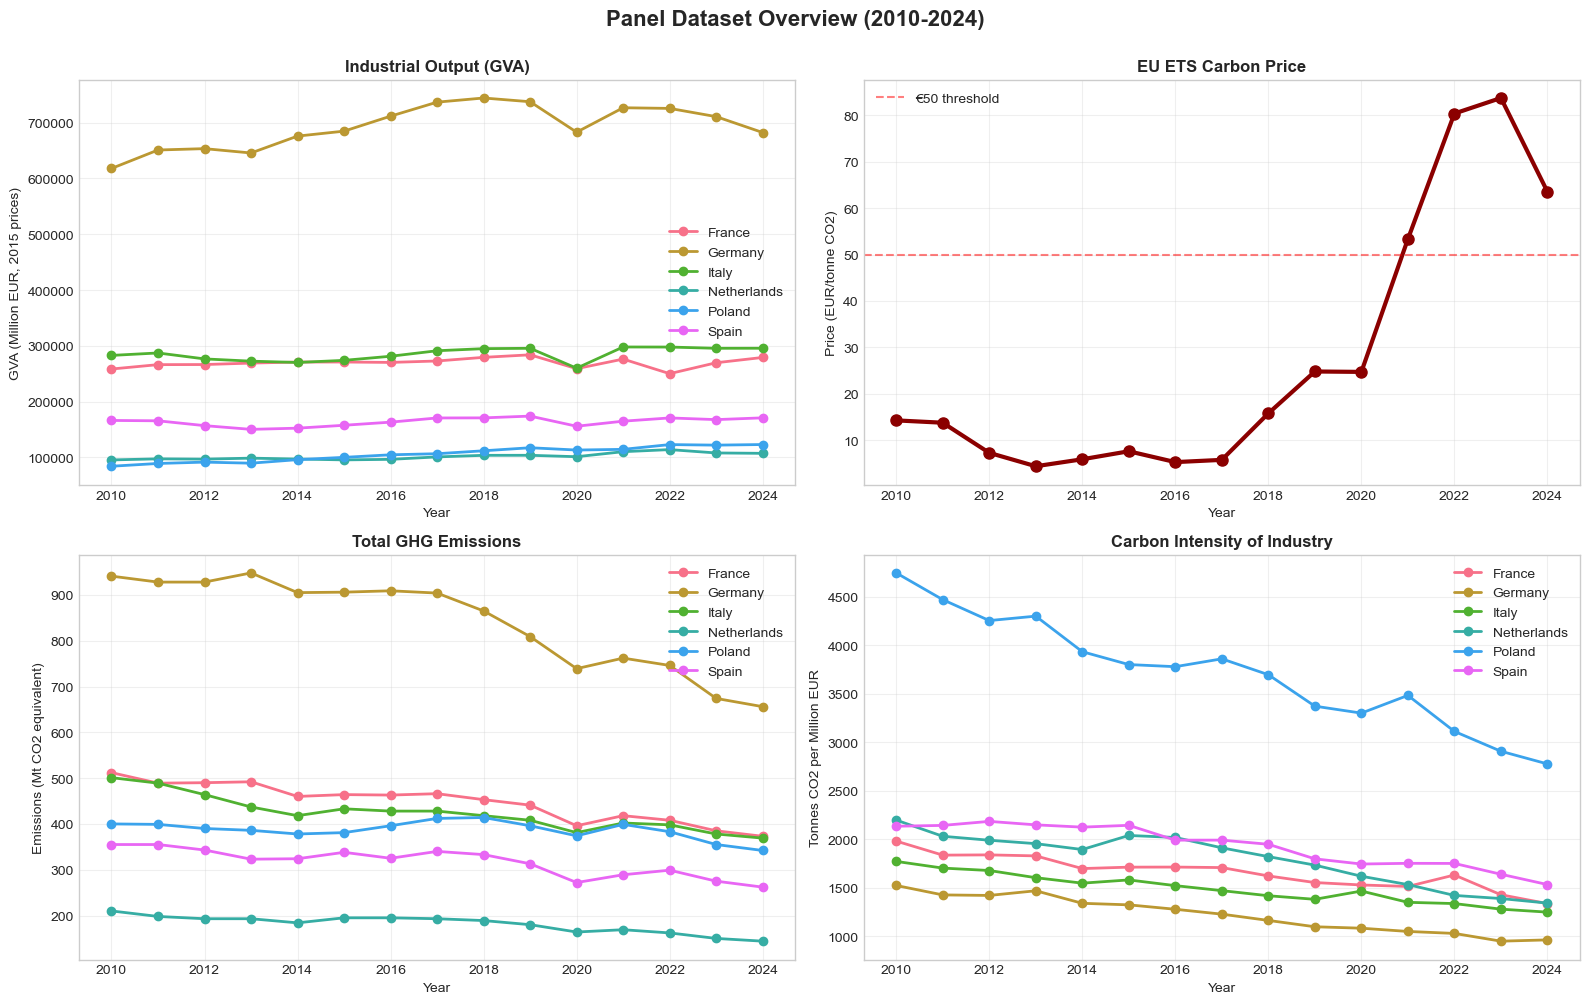


✓ Visualization saved: ../../data/processed/panel_overview.png


In [12]:
# Create overview plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Panel Dataset Overview (2010-2024)', fontsize=16, fontweight='bold', y=1.00)

# 1. Industrial GVA by country
for country in sorted(panel['country'].unique()):
    data = panel[panel['country'] == country]
    axes[0, 0].plot(data['year'], data['gva_industry_meur'], marker='o', label=country, linewidth=2)
axes[0, 0].set_title('Industrial Output (GVA)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('GVA (Million EUR, 2015 prices)')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Carbon price evolution
if 'carbon_price_eur_tonne' in panel.columns:
    price_data = panel.drop_duplicates('year')[['year', 'carbon_price_eur_tonne']].sort_values('year')
    axes[0, 1].plot(price_data['year'], price_data['carbon_price_eur_tonne'], 
                    marker='o', color='darkred', linewidth=3, markersize=8)
    axes[0, 1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='€50 threshold')
    axes[0, 1].set_title('EU ETS Carbon Price', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Year')
    axes[0, 1].set_ylabel('Price (EUR/tonne CO2)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Total GHG emissions by country
if 'total_ghg_mt_co2eq' in panel.columns:
    for country in sorted(panel['country'].unique()):
        data = panel[panel['country'] == country]
        axes[1, 0].plot(data['year'], data['total_ghg_mt_co2eq'], marker='o', label=country, linewidth=2)
    axes[1, 0].set_title('Total GHG Emissions', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Year')
    axes[1, 0].set_ylabel('Emissions (Mt CO2 equivalent)')
    axes[1, 0].legend(loc='best')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Carbon intensity
if 'carbon_intensity_t_per_meur' in panel.columns:
    for country in sorted(panel['country'].unique()):
        data = panel[panel['country'] == country]
        axes[1, 1].plot(data['year'], data['carbon_intensity_t_per_meur'], marker='o', label=country, linewidth=2)
    axes[1, 1].set_title('Carbon Intensity of Industry', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Tonnes CO2 per Million EUR')
    axes[1, 1].legend(loc='best')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
viz_path = DATA_PROCESSED / 'panel_overview.png'
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved: {viz_path}")

## Summary

The panel dataset has been successfully created and saved to `data/processed/`.

**Dataset characteristics:**
- **Cross-sectional units:** 6 EU countries
- **Time period:** 2010-2024 (15 years)
- **Total observations:** 90 country-year pairs
- **Key variables:** Industrial output, carbon prices, emissions, carbon intensity, ETS compliance

**Output files:**
1. `panel_dataset.csv` - Main dataset for analysis
3. `variable_codebook.csv` - Complete variable list
4. `panel_overview.png` - Quick visualization

**Next steps:**
1. Exploratory Data Analysis (EDA)
2. Panel regression analysis (Fixed Effects)
3. Hypothesis testing (Porter vs Pollution Haven)